In [1]:
import torch
import math
import json
import random
import os

import torch.nn as nn
from torch.nn import functional as F
from torch.nn import Transformer
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from transformers import AdamW
from transformers import get_scheduler, TrainingArguments, Trainer

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
import pdb
import numpy as np

In [2]:
# GLOBAL VARIABLES
device = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 15
MAX_SEQ_LEN = 180 # the size of each sequence in a batch. 150 should cover the length of about 90% of all sequences
NUM_EPOCHS = 25
LR = 25e-6 # learning rate
EVAL_INTERVAL = 1 # how often you want to run val data
START_TOKEN = '<START>'
END_TOKEN = '<END>'
PADDING_TOKEN = '<PAD>'

In [3]:
d_model = 144       # dimension of model. you can play around with this for embedding, since vocab size for chords is much less than vocab size for the english language (dimensions would be 512). make this divisible by num_heads (8)
num_heads = 8           # number of attention heads
num_layers = 4   # number of encoder/decoder layers
dim_feedforward = d_model * 4   # dimension of feedforward network
dropout = 0.1           # dropout rate

In [4]:
class ChordTokenizer:
    def __init__(self):
        self.vocab = [START_TOKEN, END_TOKEN, PADDING_TOKEN] # this array is just for encoding/decoding ease

    def create_vocab(self, sequences):
        for sequence in sequences:
            for chord in sequence:
                if chord not in self.vocab:
                    self.vocab.append(chord)

    def tokenize(self, song, start_token=False, end_token=False):
        chord_indices = [self.vocab.index(token) for token in song]
        if start_token:
            chord_indices.insert(0, self.vocab.index(START_TOKEN))
        if end_token:
            chord_indices.append(self.vocab.index(END_TOKEN))
        for _ in range(len(chord_indices), MAX_SEQ_LEN):
            chord_indices.append(self.vocab.index(PADDING_TOKEN))
        return torch.tensor(chord_indices)

    def decode_sequence(self, token_ids):
        return [self.idx_to_token[token_id] for token_id in token_ids]

    def get_vocab_size(self):
        return len(self.vocab)

    def __getitem__(self, token):
        if token in self.vocab:
            return self.vocab.index(token)
        else:
            raise ValueError(f"Token '{token}' not found in the vocabulary.")

In [5]:
class ChordDataset:
    def __init__(self, tokenized_input_data, tokenized_output_data, orig_chord_seqs):
        self.tokenized_input_data = tokenized_input_data
        self.tokenized_output_data = tokenized_output_data
        self.orig_chord_seqs = orig_chord_seqs

    def __len__(self):
        return len(self.tokenized_input_data)

    def get_chord_sequence(self, idx):
        return self.orig_chord_seqs[idx]

    def __getitem__(self, idx):
        return self.tokenized_input_data[idx], self.tokenized_output_data[idx]

In [6]:
def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones((sz, sz))) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

In [7]:
# open the json data file and read in the chords as a 2d array
with open('song_chords.json', 'r') as f:
    songs_data = json.load(f)

chord_sequences = []
for song in songs_data:
    if len(song['chords']) <= MAX_SEQ_LEN - 2: # -2 for start and end tokens
        chord_sequences.append(song['chords'])

In [8]:
print(f"Dataset number: {len(songs_data)}")
print(f"Final number of songs: {len(chord_sequences)}")

Dataset number: 1064
Final number of songs: 1023


In [9]:
# format the dataset with input and target sequences, create vocab, and tokenize
tokenizer = ChordTokenizer()
tokenizer.create_vocab(chord_sequences)

input_tokenized_dataset = []
output_tokenized_dataset = []
for chords in chord_sequences:
    input_tokenized_dataset.append(tokenizer.tokenize(chords, start_token=False, end_token=False))
    output_tokenized_dataset.append(tokenizer.tokenize(chords, start_token=True, end_token=True))

In [10]:
print(input_tokenized_dataset[0])
print(output_tokenized_dataset[0])

tensor([ 3,  4,  5,  6,  3,  4,  3,  3,  7,  5,  6,  3,  4,  6,  4,  5,  6,  3,
         4,  3,  3,  7,  5,  6,  3,  4,  6,  4,  5,  6,  3,  4,  3,  7,  8,  7,
         8,  7,  8,  7,  9, 10,  4,  3,  7,  5,  6,  3,  4,  6,  4,  5,  6,  3,
         4,  3,  7,  8,  7,  8,  7,  8,  7,  9, 10,  4,  3,  7,  5,  6,  3,  4,
         6,  4,  5,  6,  3,  4,  3,  3,  6,  4,  5,  6,  3,  4,  3,  3, 11,  7,
        12,  5, 13,  6,  4,  4, 14,  8, 15,  9,  8, 10,  7,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2])
tensor([ 0,  3,  4,  5,  6,  3,  4,  3,  3,  7,  5,  6,  3,  4,  6,  4,  5,  6,
         3,  4,  3,  3,  7,  5,  6,  3,  4,  6,  4,  5,  6,  3,  4,  3,  7,  8,
         7,  8,  7,  8,  7,  9, 10,  4,

In [11]:
input_data_train, input_data_val = train_test_split(input_tokenized_dataset, test_size=0.2, random_state=42)
output_data_train, output_data_val = train_test_split(output_tokenized_dataset, test_size=0.2, random_state=42)

In [12]:
train_dataset = ChordDataset(input_data_train, output_data_train, chord_sequences)
val_dataset = ChordDataset(input_data_val, output_data_val, chord_sequences)

In [13]:
NEG_INF = -1e10

def create_masks(input_batch, output_batch):
    num_songs = len(input_batch)
    look_ahead_mask = torch.full([MAX_SEQ_LEN, MAX_SEQ_LEN] , True) # all trues
    look_ahead_mask = torch.triu(look_ahead_mask, diagonal=1) # zeroes out elements below the main diagonal

    encoder_padding_mask = torch.full([num_songs, MAX_SEQ_LEN, MAX_SEQ_LEN] , False)
    decoder_padding_mask_self_attention = torch.full([num_songs, MAX_SEQ_LEN, MAX_SEQ_LEN] , False)
    decoder_padding_mask_cross_attention = torch.full([num_songs, MAX_SEQ_LEN, MAX_SEQ_LEN] , False)

    for idx in range(num_songs):

      curr_input_song = input_batch[idx]
      curr_output_song = output_batch[idx]
      try:
        input_chord_size = len(curr_input_song[:tokenizer.vocab.index(PADDING_TOKEN)])
      except ValueError:
        input_chord_size = len(curr_input_song)
      try:
        output_chord_size = len(curr_output_song[:tokenizer.vocab.index(PADDING_TOKEN)])
      except ValueError:
        output_chord_size = len(curr_output_song)

      input_chords_to_padding_mask = np.arange(input_chord_size + 1, MAX_SEQ_LEN)
      output_chords_to_padding_mask = np.arange(output_chord_size + 1, MAX_SEQ_LEN)
      encoder_padding_mask[idx, :, input_chords_to_padding_mask] = True
      encoder_padding_mask[idx, input_chords_to_padding_mask, :] = True
      decoder_padding_mask_self_attention[idx, :, output_chords_to_padding_mask] = True
      decoder_padding_mask_self_attention[idx, output_chords_to_padding_mask, :] = True
      decoder_padding_mask_cross_attention[idx, :, input_chords_to_padding_mask] = True
      decoder_padding_mask_cross_attention[idx, output_chords_to_padding_mask, :] = True

    encoder_self_attention_mask = torch.where(encoder_padding_mask, NEG_INF, 0)
    decoder_self_attention_mask =  torch.where(look_ahead_mask + decoder_padding_mask_self_attention, NEG_INF, 0)
    decoder_cross_attention_mask = torch.where(decoder_padding_mask_cross_attention, NEG_INF, 0)
    return encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask

In [14]:
# this implements the attention equation from Attention is All You Need
def self_attention(q, k, v, mask=None):
    #q, k, v are size batch_size * seq_len * num_heads * d_model/num_heads
    d_k = q.size()[-1] # d_model/num_heads
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k) # batch_size * num_heads * seq_len * seq_len
    if mask is not None:
        scaled = scaled.permute(1, 0, 2, 3) + mask
        scaled = scaled.permute(1, 0, 2, 3)
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v) # batch_size * num_heads * seq_len * d_model/num_heads
    return values, attention

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_sequence_length):
        super().__init__()
        self.max_sequence_length = max_sequence_length
        self.d_model = d_model

    def forward(self):
        # get a range of 0 to the model dimensions, skipping 2 (even numbers only)
        evens = torch.arange(0, self.d_model, 2).float()

        # this is the equation from Attention is All You Need for positional encoding, using sin and cos functions
        # you only need to find evens (not odds) because the denominator for even and odds turn out to be the same
        denominator = torch.pow(10000, evens/self.d_model)
        position = (torch.arange(self.max_sequence_length).reshape(self.max_sequence_length, 1))
        even_PE = torch.sin(position / denominator)
        odd_PE = torch.cos(position / denominator)

        # interweave the two matrices (first indice from the even, second from odd, third from even, so on)
        stacked = torch.stack([even_PE, odd_PE], dim=2)
        PE = torch.flatten(stacked, start_dim=1, end_dim=2)
        return PE

In [16]:
class SentenceEmbedding(nn.Module):
    "For a given sentence, create an embedding"
    def __init__(self, max_sequence_length, d_model, vocab):
        super().__init__()
        self.vocab_size = len(vocab)
        self.max_sequence_length = max_sequence_length
        self.embedding = nn.Embedding(self.vocab_size, d_model)
        # self.vocab = vocab
        self.position_encoder = PositionalEncoding(d_model, max_sequence_length)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x): # sentence
        x = self.embedding(x)
        pos = self.position_encoder().to(device)
        x = self.dropout(x + pos)
        return x

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.qkv_layer = nn.Linear(d_model , 3 * d_model)
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, mask):
        batch_size, sequence_length, d_model = x.size() # batch_size * seq_len * d_model
        qkv = self.qkv_layer(x) # batch_size * seq_len * (3*d_model)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim) # batch_size * seq_len * num_heads * (3*d_model/num_heads)
        qkv = qkv.permute(0, 2, 1, 3) # batch_size * num_heads * seq_len * (3*d_model/num_heads)
        q, k, v = qkv.chunk(3, dim=-1) # each q,k,v: batch_size * num_heads * seq_len * d_model/num_heads
        values, attention = self_attention(q, k, v, mask) #values are batch_size * num_heads * seq_len * n_model/num_heads
        values = values.permute(0, 2, 1, 3).reshape(batch_size, sequence_length, self.num_heads * self.head_dim) # values.size() should be the same as x.size()
        out = self.linear_layer(values) # batch_size * seq_len * d_model
        return out

In [18]:
class LayerNormalization(nn.Module):
    # layer normalization is normalization performed on every part of one feature (layer)
    def __init__(self, parameters_shape, eps=1e-5):
        super().__init__()
        self.parameters_shape=parameters_shape # typically this should be your model dimension (d_model), ex. [512]
        self.eps=eps # making sure your denominator is never 0
        self.gamma = nn.Parameter(torch.ones(parameters_shape)) # learnable parameter. [d_model]
        self.beta =  nn.Parameter(torch.zeros(parameters_shape)) # learnable parameter. [d_model]

    def forward(self, inputs): # input shape: batch_size * seq_len * d_model . input/output shape is the same
        # layer normalization is mostly for back prop and being able to learn the parameters of beta and gamma
        dims = [-(i + 1) for i in range(len(self.parameters_shape))] # perform layer normalization on last shape dimension, which is d_model
        mean = inputs.mean(dim=dims, keepdim=True) # batch_size * seq_len * 1 (the mean is 1 dim)
        var = ((inputs - mean) ** 2).mean(dim=dims, keepdim=True) # calculate variance and standard deviation
        std = (var + self.eps).sqrt()
        y = (inputs - mean) / std # batch_size * seq_len * d_model, brings last dimension back to d_model
        out = self.gamma * y + self.beta
        return out # batch_size * seq_len * d_model

In [19]:
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.kv_layer = nn.Linear(d_model, 2 * d_model)
        self.q_layer = nn.Linear(d_model, d_model)
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, y, mask): # you can find shapes of this function at 2:48 of the 3 hr video
        batch_size, sequence_length, d_model = x.size() # batch_size * seq_len * d_model
        kv = self.kv_layer(x)
        q = self.q_layer(y)
        kv = kv.reshape(batch_size, sequence_length, self.num_heads, 2 * self.head_dim)
        q = q.reshape(batch_size, sequence_length, self.num_heads, self.head_dim)
        kv = kv.permute(0, 2, 1, 3)
        q = q.permute(0, 2, 1, 3)
        k, v = kv.chunk(2, dim=-1)
        values, attention = self_attention(q, k, v, mask) # We don't need the mask for cross attention, removing in outer function!
        values = values.permute(0, 2, 1, 3).reshape(batch_size, sequence_length, d_model)
        out = self.linear_layer(values)
        return out # batch_size * seq_len * d_model

In [20]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, ffn_hidden, num_heads, dropout):
        super(EncoderLayer, self).__init__()
        self.attention = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.norm1 = LayerNormalization(parameters_shape=[d_model])
        self.dropout1 = nn.Dropout(p=dropout)
        self.ffn = PositionwiseFeedForward(d_model=d_model, ffn_hidden=ffn_hidden, dropout=dropout)
        self.norm2 = LayerNormalization(parameters_shape=[d_model])
        self.dropout2 = nn.Dropout(p=dropout)

    def forward(self, x, self_attention_mask):
        residual_x = x.clone() # batch_size * max_seq_len * d_model
        x = self.attention(x, mask=self_attention_mask)
        x = self.dropout1(x)
        x = self.norm1(x + residual_x)
        residual_x = x.clone()
        x = self.ffn(x)
        x = self.dropout2(x)
        x = self.norm2(x + residual_x)
        return x # shape should stay consistent through whole forward pass (it will change within some functions, but not on this level)

In [21]:
class SequentialEncoder(nn.Sequential):
    def forward(self, *inputs):
        x, self_attention_mask  = inputs
        for module in self._modules.values():
            x = module(x, self_attention_mask)
        return x

In [22]:
class Encoder(nn.Module):
    def __init__(self, d_model, ffn_hidden, num_heads, dropout, num_layers, max_sequence_length, vocab):
        super().__init__()
        self.sentence_embedding = SentenceEmbedding(max_sequence_length, d_model, vocab)
        self.layers = SequentialEncoder(*[EncoderLayer(d_model, ffn_hidden, num_heads, dropout) for _ in range(num_layers)])

    def forward(self, x, self_attention_mask):
        x = self.sentence_embedding(x)
        x = self.layers(x, self_attention_mask)
        return x

In [23]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, ffn_hidden, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, ffn_hidden) # d_model * dim_feedforward
        self.linear2 = nn.Linear(ffn_hidden, d_model) # d_model * d_model
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x): # batch * seq_len * d_model
        x = self.linear1(x) # batch * seq_len * dim_feedforward
        x = self.relu(x)
        x = self.dropout(x)
        x = self.linear2(x) # batch * seq_len * d_model
        return x

In [24]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, ffn_hidden, num_heads, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attention = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.layer_norm1 = LayerNormalization(parameters_shape=[d_model])
        self.dropout1 = nn.Dropout(p=dropout)

        self.encoder_decoder_attention = MultiHeadCrossAttention(d_model=d_model, num_heads=num_heads)
        self.layer_norm2 = LayerNormalization(parameters_shape=[d_model])
        self.dropout2 = nn.Dropout(p=dropout)

        self.ffn = PositionwiseFeedForward(d_model=d_model, ffn_hidden=ffn_hidden, dropout=dropout)
        self.layer_norm3 = LayerNormalization(parameters_shape=[d_model])
        self.dropout3 = nn.Dropout(p=dropout)

    def forward(self, x, y, self_attention_mask, cross_attention_mask):
        _y = y.clone() #batch_size * seq_len * d_model, should be consistent throughout forward function
        y = self.self_attention(y, mask=self_attention_mask)
        y = self.dropout1(y)
        y = self.layer_norm1(y + _y)

        _y = y.clone()
        y = self.encoder_decoder_attention(x, y, mask=cross_attention_mask)
        y = self.dropout2(y)
        y = self.layer_norm2(y + _y)

        _y = y.clone()
        y = self.ffn(y)
        y = self.dropout3(y)
        y = self.layer_norm3(y + _y)
        return y # batch_size * seq_len * d_model

In [25]:
class SequentialDecoder(nn.Sequential):
    def forward(self, *inputs):
        x, y, self_attention_mask, cross_attention_mask = inputs
        for module in self._modules.values():
            y = module(x, y, self_attention_mask, cross_attention_mask)
        return y

In [26]:
class Decoder(nn.Module):
    def __init__(self,
                 d_model,
                 ffn_hidden,
                 num_heads,
                 dropout,
                 num_layers,
                 max_sequence_length,
                 vocab):
        super().__init__()
        self.sentence_embedding = SentenceEmbedding(max_sequence_length, d_model, vocab)
        self.layers = SequentialDecoder(*[DecoderLayer(d_model, ffn_hidden, num_heads, dropout) for _ in range(num_layers)])

    def forward(self, x, y, self_attention_mask, cross_attention_mask):
        # x and y are batch_size * seq_len * d_model
        # mask is seq_len * seq_len
        y = self.sentence_embedding(y)
        y = self.layers(x, y, self_attention_mask, cross_attention_mask)
        return y

In [27]:
class Transformer(nn.Module):
    def __init__(self,
                d_model,
                ffn_hidden,
                num_heads,
                dropout,
                num_layers,
                max_sequence_length,
                vocab_size,
                vocab,
                ):
        super().__init__()
        self.encoder = Encoder(d_model, ffn_hidden, num_heads, dropout, num_layers, max_sequence_length, vocab)
        self.decoder = Decoder(d_model, ffn_hidden, num_heads, dropout, num_layers, max_sequence_length, vocab)
        self.linear = nn.Linear(d_model, vocab_size)
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    def forward(self, x, y, encoder_self_attention_mask=None, decoder_self_attention_mask=None, decoder_cross_attention_mask=None): # x, y are batch of sentences
        x = self.encoder(x, encoder_self_attention_mask)
        out = self.decoder(x, y, decoder_self_attention_mask, decoder_cross_attention_mask)
        out = self.linear(out)
        return out

In [28]:
train_loader = DataLoader(train_dataset, BATCH_SIZE)
val_loader = DataLoader(val_dataset, BATCH_SIZE)
iterator = iter(train_loader)

In [29]:
for batch_num, batch in enumerate(iterator):
    print(batch)
    if batch_num > 1:
        break

[tensor([[ 11,  86,  41,  ...,   2,   2,   2],
        [ 62,   6,   3,  ...,   2,   2,   2],
        [ 13,   4,  11,  ...,   2,   2,   2],
        ...,
        [ 10,  59, 340,  ...,   2,   2,   2],
        [139,  56,   3,  ...,   2,   2,   2],
        [  7,   3,   4,  ...,   2,   2,   2]]), tensor([[  0,  11,  86,  ...,   2,   2,   2],
        [  0,  62,   6,  ...,   2,   2,   2],
        [  0,  13,   4,  ...,   2,   2,   2],
        ...,
        [  0,  10,  59,  ...,   2,   2,   2],
        [  0, 139,  56,  ...,   2,   2,   2],
        [  0,   7,   3,  ...,   2,   2,   2]])]
[tensor([[  4,   5,   3,  ...,   2,   2,   2],
        [220,   5,  10,  ...,   2,   2,   2],
        [ 14,  99,   4,  ...,   2,   2,   2],
        ...,
        [  7,   4,   3,  ...,   2,   2,   2],
        [ 11,  14,   4,  ...,   2,   2,   2],
        [  4,  11,   7,  ...,   2,   2,   2]]), tensor([[  0,   4,   5,  ...,   2,   2,   2],
        [  0, 220,   5,  ...,   2,   2,   2],
        [  0,  14,  99,  ...,   2

In [30]:
model = Transformer(d_model,
                    dim_feedforward,
                    num_heads,
                    dropout,
                    num_layers,
                    MAX_SEQ_LEN,
                    tokenizer.get_vocab_size(),
                    tokenizer.vocab)

In [31]:
criterian = nn.CrossEntropyLoss(ignore_index=tokenizer.vocab.index(PADDING_TOKEN),
                                reduction='none')

# When computing the loss, we are ignoring cases when the label is the padding token
for params in model.parameters():
    if params.dim() > 1:
        nn.init.xavier_uniform_(params)

optim = torch.optim.Adam(model.parameters(), lr=LR) #.00001 v .00005

In [34]:
model.train()
model.to(device)
total_loss = 0
graph_train_losses = []
for epoch in tqdm(range(NUM_EPOCHS)):
    epoch_training_loss = 0
    # print(f"Epoch {epoch}")
    iterator = iter(train_loader)
    for batch_num, batch in enumerate(iterator):
        model.train()
        input_batch, output_batch = batch
        input_batch, output_batch = input_batch.to(device), output_batch.to(device)
        encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask = create_masks(input_batch, output_batch)
        optim.zero_grad()
        train_predictions = model(input_batch,
                            output_batch,
                            encoder_self_attention_mask.to(device),
                            decoder_self_attention_mask.to(device),
                            decoder_cross_attention_mask.to(device)
                            )
        labels = output_batch
        loss = criterian(
            train_predictions.view(-1, tokenizer.get_vocab_size()).to(device),
            labels.view(-1).to(device)
            ).to(device)
        valid_indicies = torch.where(labels.view(-1) == tokenizer.vocab.index(PADDING_TOKEN), False, True)
        loss = loss.sum() / valid_indicies.sum()
        loss.backward()
        optim.step()
        train_pred_probs = torch.softmax(train_predictions, dim=-1)
        train_pred_indices = torch.argmax(train_pred_probs, dim=-1)
        total_loss += loss.item()
        epoch_training_loss += loss.item()

    if (epoch + 1) % EVAL_INTERVAL == 0:
        model.eval()
        val_loss = 0
            # print(f"Epoch {epoch}")
        with torch.no_grad():
            iterator = iter(val_loader)
            for batch_num, batch in enumerate(iterator):
                input_batch, output_batch = batch
                input_batch, output_batch = input_batch.to(device), output_batch.to(device)
                encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask = create_masks(input_batch, output_batch)
                optim.zero_grad()
                predictions = model(input_batch,
                                    output_batch,
                                    encoder_self_attention_mask.to(device),
                                    decoder_self_attention_mask.to(device),
                                    decoder_cross_attention_mask.to(device)
                                    )
                labels = output_batch
                loss = criterian(
                    predictions.view(-1, tokenizer.get_vocab_size()).to(device),
                    labels.view(-1).to(device)
                    ).to(device)
                valid_indicies = torch.where(labels.view(-1) == tokenizer.vocab.index(PADDING_TOKEN), False, True)
                loss = loss.sum() / valid_indicies.sum()
                val_loss += loss.item()
                # Convert the predictions to probabilities
                pred_probs = torch.softmax(predictions, dim=-1)
                pred_indices = torch.argmax(pred_probs, dim=-1)
            # Print the predictions and corresponding ground truth
            print(f"Epoch {epoch} validation loss : {val_loss}")

    print("Input batch:", input_batch.tolist())
    print("Output batch:", output_batch.tolist())
    print("Predictions:", train_pred_indices.tolist())
    epoch_training_loss = epoch_training_loss / NUM_EPOCHS
    if (epoch + 1) % EVAL_INTERVAL == 0:
        print(f"Epoch {epoch} training loss : {epoch_training_loss}")
    graph_train_losses.append(epoch_training_loss)

print(f"Total training loss : {total_loss}")



  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0 validation loss : 37.92162227630615
Input batch: [[4, 62, 4, 62, 4, 62, 4, 62, 4, 62, 3, 4, 62, 3, 4, 62, 4, 62, 4, 62, 4, 62, 4, 62, 3, 4, 62, 3, 4, 62, 4, 62, 4, 62, 4, 62, 4, 62, 3, 4, 62, 3, 4, 62, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], [13, 13, 13, 13, 173, 173, 86, 249, 41, 71, 41, 71, 13, 13, 13, 4, 12, 7, 14, 13, 13, 13, 13, 13, 4, 12, 7, 14, 13, 13, 13, 13, 13, 4, 12, 7, 14, 13, 13, 13, 13, 13, 4, 12, 7, 14, 13, 13, 173, 173, 86, 249, 41, 71, 41, 71, 13, 13, 173, 86, 249, 41, 71, 41, 71, 13, 13, 173, 86, 249, 41, 71, 41, 71, 13, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

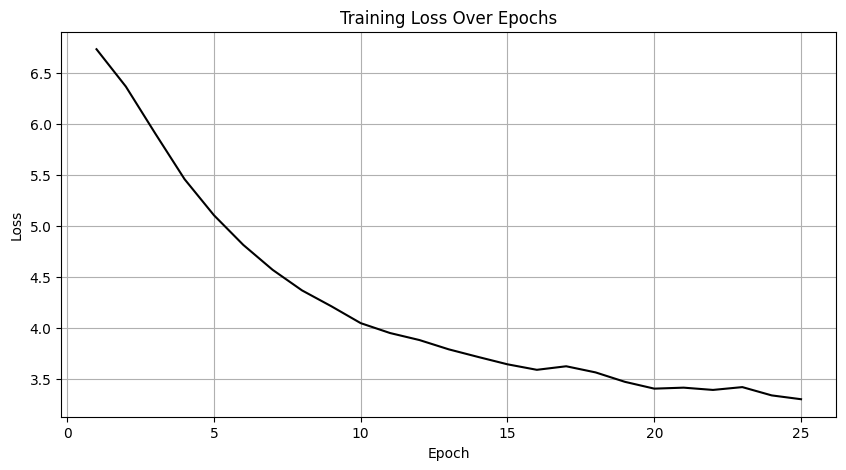

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), graph_train_losses, linestyle='-', color='black')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [37]:
# save the model
# save_directory = "saved_models"
# os.makedirs(save_directory, exist_ok=True)
# model_save_path = os.path.join(save_directory, "generate_chords_model.pth")

# torch.save(model.state_dict(), model_save_path)
# print(f"Model saved to {model_save_path}")